# Notebook 3 — Serie horaria de O₃ en UIZ

Actividad de **Module 1, P2**. Analizamos el ozono horario de UIZ (UAM Iztapalapa) y resolvemos los seis incisos de la fotografía:

1. Contar los huecos y justificar cómo tratarlos.
2. Graficar la serie y su ACF hasta 72 horas.
3. Aplicar ADF y KPSS.
4. Restar la media por hora del día y repetir las pruebas.
5. Restar la media por **mes × hora** y repetir las pruebas.
6. Calcular la diferencia de 24 horas, repetir las pruebas y comparar su ACF y varianza con el inciso anterior.

**Ejecución:** ejecutar todas las celdas en orden. Este notebook incluye en su interior las 5088 filas de O₃–UIZ de la copia del CSV que ya estaba en Module 1, correspondiente a **enero–julio de 2026**. No requiere otros archivos para reproducir los resultados y no guarda CSV, imágenes ni carpetas. Los datos son mediciones reales de la copia disponible, no datos sintéticos. Se conserva la unidad numérica original del CSV (código `1`), sin conversiones de unidades.

Fuente indicada por el profesor: [CSV horario 2026 de SIMAT](https://aire.cdmx.gob.mx/descargas/Opendata/anuales_horarios_gz/contaminantes_2026.csv.gz). El archivo remoto puede actualizarse durante el año; nuestra copia fija no debe confundirse con el año completo o con la última versión del servidor.

In [1]:
import base64
import gzip
import hashlib
import io
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels
from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tools.sm_exceptions import InterpolationWarning
from IPython.display import display, Markdown

ALPHA = 0.05
MAX_GAP = 6  # Sólo rellenaremos huecos internos de hasta 6 horas completas.
MAX_LAG = 72
UNIDAD = "unidad original del CSV (código 1)"
plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True, "grid.alpha": 0.20})
print(f"Versiones: pandas {pd.__version__}, NumPy {np.__version__}, statsmodels {statsmodels.__version__}")

Versiones: pandas 2.2.3, NumPy 2.1.3, statsmodels 0.14.4


**Datos incorporados y reproducibilidad.** La cadena de la siguiente celda es únicamente el CSV filtrado a O₃–UIZ, comprimido en memoria. La verificación SHA-256 comprueba que se recuperan exactamente esas filas. `ACTUALIZAR_DESDE_WEB=False` mantiene el mismo periodo y resultados; si se cambia a `True`, se descarga el archivo del profesor en memoria y se filtra la misma estación y contaminante. Nunca se escribe el archivo descargado en disco.

In [2]:
URL_DATOS = "https://aire.cdmx.gob.mx/descargas/Opendata/anuales_horarios_gz/contaminantes_2026.csv.gz"
ACTUALIZAR_DESDE_WEB = False
CSV_SHA256 = '2aae5acabc638dede643bccc8d123d8b437811d52d7fdaf037310a6080b22188'
CSV_GZIP_BASE64 = '...'

if ACTUALIZAR_DESDE_WEB:
    import requests
    respuesta = requests.get(URL_DATOS, timeout=45)
    respuesta.raise_for_status()
    contenido = respuesta.content
    if contenido[:2] == b"\x1f\x8b":
        contenido = gzip.decompress(contenido)
    texto = contenido.decode("utf-8-sig")
    lineas = texto.splitlines()
    inicio = next(i for i, linea in enumerate(lineas)
                  if "id_station" in linea and "id_parameter" in linea and "date" in linea)
    base = pd.read_csv(io.StringIO("\n".join(lineas[inicio:])),
                       usecols=["date", "id_station", "id_parameter", "valor", "unit"])
    datos = base.loc[base["id_station"].eq("UIZ") & base["id_parameter"].eq("O3")].copy()
    fuente_usada = "Descarga oficial en memoria; periodo según versión del servidor"
else:
    contenido = gzip.decompress(base64.b64decode(CSV_GZIP_BASE64))
    assert hashlib.sha256(contenido).hexdigest() == CSV_SHA256
    datos = pd.read_csv(io.BytesIO(contenido))
    fuente_usada = "Copia incorporada: contaminantes_2026 (1).csv, enero–julio 2026"

if datos.empty:
    raise ValueError("No hay registros O3 de UIZ en la fuente seleccionada.")
datos["date"] = pd.to_datetime(datos["date"], errors="raise")
datos["valor"] = pd.to_numeric(datos["valor"], errors="coerce")
if datos["date"].duplicated().any():
    raise ValueError("Hay fechas duplicadas para O3–UIZ; hay que revisarlas antes de analizar.")
if not (datos["date"] == datos["date"].dt.floor("h")).all():
    raise ValueError("Se esperaban fechas exactamente horarias.")
negativos = int(datos["valor"].lt(0).sum())
datos.loc[datos["valor"].lt(0), "valor"] = np.nan
serie_original = datos.set_index("date")["valor"].sort_index().asfreq("h").rename("O3_UIZ")
print(f"Fuente: {fuente_usada}")
print(f"Periodo disponible: {serie_original.index.min()} a {serie_original.index.max()}")
print(f"Código de unidad: {sorted(datos['unit'].dropna().unique().tolist())}")
display(datos.head())

Fuente: Copia incorporada: contaminantes_2026 (1).csv, enero–julio 2026
Periodo disponible: 2026-01-01 00:00:00 a 2026-07-31 23:00:00
Código de unidad: [1]


,date,id_station,id_parameter,valor,unit
0,2026-01-01 00:00:00,UIZ,O3,14.0,1
1,2026-01-01 01:00:00,UIZ,O3,5.0,1
2,2026-01-01 02:00:00,UIZ,O3,2.0,1
3,2026-01-01 03:00:00,UIZ,O3,3.0,1
4,2026-01-01 04:00:00,UIZ,O3,3.0,1


## A. Huecos y decisión de tratamiento

Primero reconstruimos el calendario horario. Un hueco puede ser una hora que no aparece como fila o una fila cuya medición está vacía. **No reemplazamos huecos por cero**, porque cero sería una medición de ozono. Tampoco quitamos filas y pegamos horas separadas: eso alteraría qué significan los rezagos de 24 y 72 horas.

Se interpola linealmente en tiempo **sólo un hueco interno completo de hasta 6 horas**, con mediciones válidas a ambos lados. Seis horas es una decisión explícita (un cuarto del ciclo diario), no una regla universal. Los huecos más largos quedan vacíos y no se rellenan parcialmente. La interpolación puede suavizar la serie y afectar ACF/varianza; al final comprobamos sensibilidad al umbral de 3 horas.

Para ADF/KPSS y las comparaciones seleccionamos el **bloque horario completo más largo** después de ese tratamiento. Todas las transformaciones se construyen sobre ese mismo bloque y se comparan en las mismas fechas. Las conclusiones se restringen a ese tramo, no al año completo.

Interpoladas: 171; todavía vacías: 57
Bloque seleccionado: 2026-03-01 03:00:00 a 2026-06-20 09:00:00 (2671 horas)
Horas interpoladas dentro del bloque: 93


,horas_esperadas,horas_observadas,filas_sin_valor,horas_sin_fila,horas_sin_medicion,porcentaje_faltante,numero_de_huecos,mayor_hueco_h,valores_negativos_convertidos_a_NaN
0,5088,4860,228,0,228,4.481,68,49,0


,inicio,fin,horas
54,2026-06-20 10:00:00,2026-06-22 10:00:00,49
17,2026-02-28 19:00:00,2026-03-01 02:00:00,8
39,2026-05-11 22:00:00,2026-05-12 03:00:00,6
66,2026-07-27 11:00:00,2026-07-27 15:00:00,5
50,2026-06-04 23:00:00,2026-06-05 02:00:00,4
51,2026-06-10 23:00:00,2026-06-11 02:00:00,4
63,2026-07-16 23:00:00,2026-07-17 02:00:00,4
53,2026-06-16 23:00:00,2026-06-17 02:00:00,4
42,2026-05-14 11:00:00,2026-05-14 14:00:00,4
5,2026-01-17 23:00:00,2026-01-18 02:00:00,4


,numero_de_huecos
horas_por_hueco,
1,19
2,3
3,33
4,9
5,1
6,1
8,1
49,1


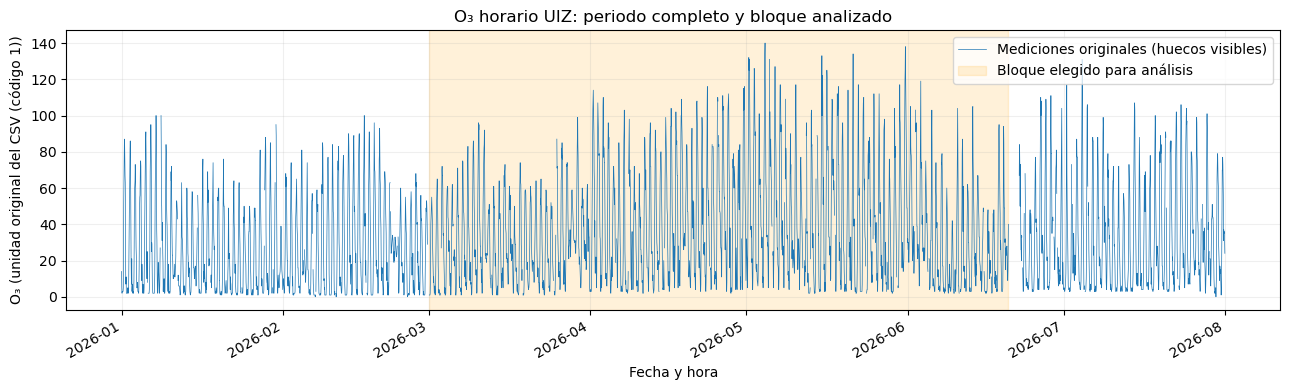

**Decisión:** había 228 horas sin medición (4.48%). Rellenamos 171 horas en huecos cortos y dejamos 57 sin estimar. El análisis usa 2671 horas consecutivas; no concatenamos tramos separados.

In [3]:
faltante = serie_original.isna()
id_hueco = faltante.ne(faltante.shift(fill_value=False)).cumsum()
huecos = []
for _, tramo in serie_original[faltante].groupby(id_hueco[faltante]):
    huecos.append({"inicio": tramo.index[0], "fin": tramo.index[-1], "horas": len(tramo)})
tabla_huecos = pd.DataFrame(huecos, columns=["inicio", "fin", "horas"])
resumen_huecos = pd.DataFrame([{
    "horas_esperadas": len(serie_original), "horas_observadas": int(serie_original.notna().sum()),
    "filas_sin_valor": int(datos["valor"].isna().sum()),
    "horas_sin_fila": len(serie_original) - len(datos),
    "horas_sin_medicion": int(faltante.sum()), "porcentaje_faltante": 100 * faltante.mean(),
    "numero_de_huecos": len(tabla_huecos),
    "mayor_hueco_h": int(tabla_huecos["horas"].max()) if len(tabla_huecos) else 0,
    "valores_negativos_convertidos_a_NaN": negativos,
}])
display(resumen_huecos.round(3))
display(tabla_huecos.sort_values("horas", ascending=False).head(12))
display(tabla_huecos["horas"].value_counts().sort_index().rename_axis("horas_por_hueco").to_frame("numero_de_huecos"))


def tratar_huecos(serie, max_gap):
    missing = serie.isna()
    grupos = missing.ne(missing.shift(fill_value=False)).cumsum()
    longitud = missing.groupby(grupos).transform("sum")
    candidato = serie.interpolate(method="time", limit_area="inside")
    rellenar = missing & longitud.le(max_gap) & candidato.notna()
    tratada = serie.copy()
    tratada.loc[rellenar] = candidato.loc[rellenar]
    return tratada, rellenar


def mayor_bloque(serie):
    validos = serie.notna()
    grupos = validos.ne(validos.shift(fill_value=False)).cumsum()
    bloques = [bloque for _, bloque in serie[validos].groupby(grupos[validos])]
    if not bloques:
        raise ValueError("No hay un bloque válido para analizar.")
    return max(bloques, key=len).copy()


serie_tratada, interpoladas = tratar_huecos(serie_original, MAX_GAP)
y = mayor_bloque(serie_tratada)
assert y.notna().all()
assert (y.index.to_series().diff().dropna() == pd.Timedelta(hours=1)).all()
assert serie_tratada.loc[serie_original.notna()].equals(serie_original.dropna())
print(f"Interpoladas: {int(interpoladas.sum())}; todavía vacías: {int(serie_tratada.isna().sum())}")
print(f"Bloque seleccionado: {y.index[0]} a {y.index[-1]} ({len(y)} horas)")
print(f"Horas interpoladas dentro del bloque: {int(interpoladas.reindex(y.index).sum())}")
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(serie_original.index, serie_original, linewidth=0.5, label="Mediciones originales (huecos visibles)")
ax.axvspan(y.index[0], y.index[-1], color="orange", alpha=0.15, label="Bloque elegido para análisis")
ax.set(title="O₃ horario UIZ: periodo completo y bloque analizado", xlabel="Fecha y hora", ylabel=f"O₃ ({UNIDAD})")
ax.legend(loc="upper right")
fig.autofmt_xdate();fig.tight_layout();plt.show()
display(Markdown(f"**Decisión:** había {int(faltante.sum())} horas sin medición ({100*faltante.mean():.2f}%). Rellenamos {int(interpoladas.sum())} horas en huecos cortos y dejamos {int(serie_tratada.isna().sum())} sin estimar. El análisis usa {len(y)} horas consecutivas; no concatenamos tramos separados."))

## B. Serie y ACF hasta 72 horas

**ACF(k)** mide la correlación de la serie con ella misma $k$ horas antes. Un pico en 24, 48 o 72 horas puede indicar un patrón diario persistente; no prueba por sí solo una raíz unitaria. El rezago cero vale 1 por definición y se omite para facilitar la lectura.

Construimos las cuatro variantes sobre el bloque seleccionado. Para compararlas reservamos sus primeras 24 horas como antecedentes de la diferencia diaria. Así la serie base, los dos centrados y la diferencia tienen **las mismas fechas y cantidad de observaciones** en los gráficos, pruebas y varianzas principales. Las bandas de ACF son aproximadas (Bartlett, 95%), no una prueba conjunta para los 72 rezagos.

Muestra común: 2647 horas, 2026-03-02 03:00:00 a 2026-06-20 09:00:00


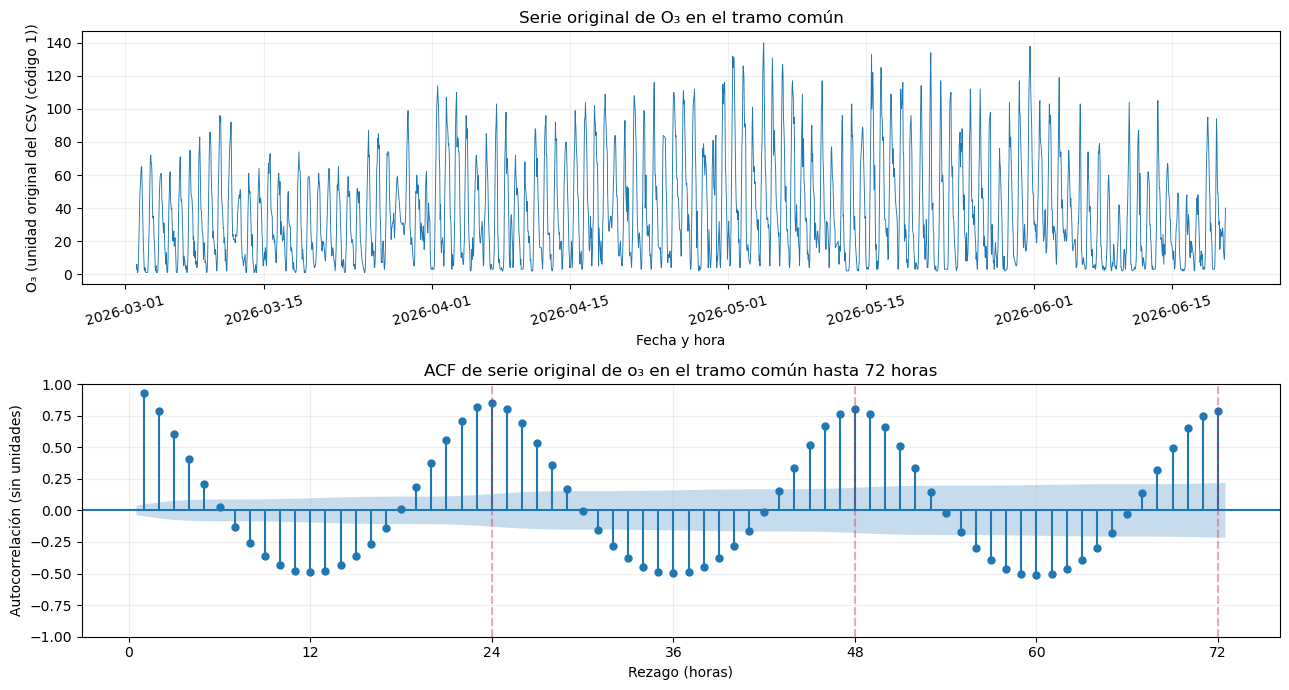

**Lectura:** ACF(24) = 0.849, ACF(48) = 0.802 y ACF(72) = 0.785. Comparamos observaciones separadas por horas reales; los picos diarios se contrastarán con las transformaciones siguientes.

In [4]:
# Las medias se estiman en el bloque completo, antes de recortar las 24 horas.
horas = pd.Series(y.index.hour, index=y.index, name="hora")
meses = pd.Series(y.index.to_period("M"), index=y.index, name="mes")
media_hora = y.groupby(horas).transform("mean")
media_mes_hora = y.groupby([meses, horas]).transform("mean")
variantes_completas = pd.DataFrame({
    "Original": y,
    "Sin media por hora": y - media_hora,
    "Sin media mes × hora": y - media_mes_hora,
    "Diferencia 24 h": y.diff(24),
})
comparables = variantes_completas.iloc[24:].copy()
assert not comparables.isna().any().any()
assert len(comparables) > 2 * MAX_LAG + 5
assert (comparables.index.to_series().diff().dropna() == pd.Timedelta(hours=1)).all()
print(f"Muestra común: {len(comparables)} horas, {comparables.index[0]} a {comparables.index[-1]}")


def graficar_serie_acf(serie, titulo, color="#1f77b4"):
    fig, axes = plt.subplots(2, 1, figsize=(13, 7))
    axes[0].plot(serie.index, serie, linewidth=0.65, color=color)
    axes[0].set(title=titulo, xlabel="Fecha y hora", ylabel=f"O₃ ({UNIDAD})")
    axes[0].tick_params(axis="x", rotation=15)
    plot_acf(serie.to_numpy(), lags=MAX_LAG, zero=False, alpha=0.05, fft=True, ax=axes[1])
    axes[1].set(title=f"ACF de {titulo.lower()} hasta {MAX_LAG} horas",
                xlabel="Rezago (horas)", ylabel="Autocorrelación (sin unidades)",
                xticks=np.arange(0, MAX_LAG + 1, 12))
    for lag in [24, 48, 72]:
        axes[1].axvline(lag, linestyle="--", alpha=0.35, color="crimson")
    fig.tight_layout();plt.show()


graficar_serie_acf(comparables["Original"], "Serie original de O₃ en el tramo común")
acf_original = acf(comparables["Original"], nlags=MAX_LAG, fft=True)
display(Markdown(f"**Lectura:** ACF(24) = {acf_original[24]:.3f}, ACF(48) = {acf_original[48]:.3f} y ACF(72) = {acf_original[72]:.3f}. Comparamos observaciones separadas por horas reales; los picos diarios se contrastarán con las transformaciones siguientes."))

## C. ADF y KPSS en la serie original

| Prueba | Hipótesis nula $H_0$ | Si p < 0.05 |
|---|---|---|
| ADF | La serie tiene una raíz unitaria | Se rechaza esa raíz unitaria; esto no elimina toda posible estacionalidad o cambio de régimen. |
| KPSS | La serie es estacionaria alrededor de una constante | Se rechaza estacionariedad de nivel. |

Usamos `regression="c"` en ambas pruebas. ADF selecciona rezagos por AIC con un máximo de 72 horas para permitir dependencia de hasta tres días; KPSS usa `nlags="auto"`. **Los resultados deben leerse juntos:** ADF que rechaza y KPSS que no rechaza son compatibles con estacionariedad de nivel. Si ambos rechazan, no declaramos estacionariedad: pueden influir estacionalidad, cambios de nivel o diferencias entre las pruebas.

KPSS sólo tabula p-values entre 0.01 y 0.10: cuando corresponde reportamos **≤0.01** o **≥0.10**, no esos límites como valores exactos. Las pruebas y las medias estimadas son diagnósticos exploratorios, no certificados de estacionariedad.

In [5]:
def diagnosticar(serie, nombre):
    valores = serie.to_numpy(dtype=float)
    if not np.isfinite(valores).all():
        raise ValueError("ADF/KPSS requieren una serie finita y horaria consecutiva.")
    adf_stat, adf_p, adf_lags, adf_n, adf_crit, _ = adfuller(
        valores, regression="c", maxlag=MAX_LAG, autolag="AIC")
    with warnings.catch_warnings(record=True) as avisos:
        warnings.simplefilter("always", InterpolationWarning)
        k_stat, k_p, k_lags, k_crit = kpss(valores, regression="c", nlags="auto")
    fuera_tabla = any(issubclass(a.category, InterpolationWarning) for a in avisos)
    k_texto = ("≤0.01" if fuera_tabla and k_p <= 0.01 else
               "≥0.10" if fuera_tabla and k_p >= 0.10 else f"{k_p:.4f}")
    adf_rechaza, kpss_rechaza = adf_p < ALPHA, k_p < ALPHA
    if adf_rechaza and not kpss_rechaza:
        lectura = "Compatible con estacionariedad de nivel (en este tramo)"
    elif not adf_rechaza and kpss_rechaza:
        lectura = "Evidencia de no estacionariedad"
    elif adf_rechaza and kpss_rechaza:
        lectura = "Ambas rechazan: diagnóstico de nivel no concluyente"
    else:
        lectura = "Ninguna rechaza: resultado inconcluso / posible baja potencia"
    return {"serie": nombre, "n_horas": len(serie), "ADF_estadistico": adf_stat,
            "ADF_p": adf_p, "ADF_rezagos": adf_lags, "ADF_n_efectivo": adf_n,
            "ADF_critico_5pct": adf_crit["5%"], "ADF_rechaza_raiz": adf_rechaza,
            "KPSS_estadistico": k_stat, "KPSS_p_reportado": k_texto,
            "KPSS_p_limite_numerico": k_p, "KPSS_rezagos": k_lags,
            "KPSS_critico_5pct": k_crit["5%"], "KPSS_rechaza_nivel": kpss_rechaza,
            "lectura_conjunta": lectura}


resultados_pruebas = {}
resultados_pruebas["Original"] = diagnosticar(comparables["Original"], "Original")
display(pd.DataFrame([resultados_pruebas["Original"]]).T)
display(Markdown("**Interpretación conjunta:** " + resultados_pruebas["Original"]["lectura_conjunta"] + ". El ciclo diario y los cambios de media deben estudiarse aunque ADF rechace su hipótesis."))

,0
serie,Original
n_horas,2647
ADF_estadistico,-3.058064
ADF_p,0.029816
ADF_rezagos,69
ADF_n_efectivo,2577
ADF_critico_5pct,-2.862662
ADF_rechaza_raiz,True
KPSS_estadistico,1.251012
KPSS_p_reportado,≤0.01


**Interpretación conjunta:** Ambas rechazan: diagnóstico de nivel no concluyente. El ciclo diario y los cambios de media deben estudiarse aunque ADF rechace su hipótesis.

## D. Restar la media de cada hora del día

$$z_t = y_t - \bar y_{h(t)}.$$

Estimar una media para las 00:00, otra para las 01:00, etc., y restarla a cada observación elimina el **perfil diario promedio fijo**. Puede quedar una evolución por mes u otra dependencia temporal. Se usan sólo las horas del bloque elegido; no se toma información de otras estaciones ni de otros contaminantes.

,mean,count,std
hora_del_dia,,,
0,15.999,111,10.024
1,15.638,111,10.245
2,14.782,111,10.229
3,13.227,112,9.723
4,11.821,112,8.848
5,7.339,112,6.438
6,5.411,112,5.160
7,9.652,112,6.584
8,20.664,112,9.804


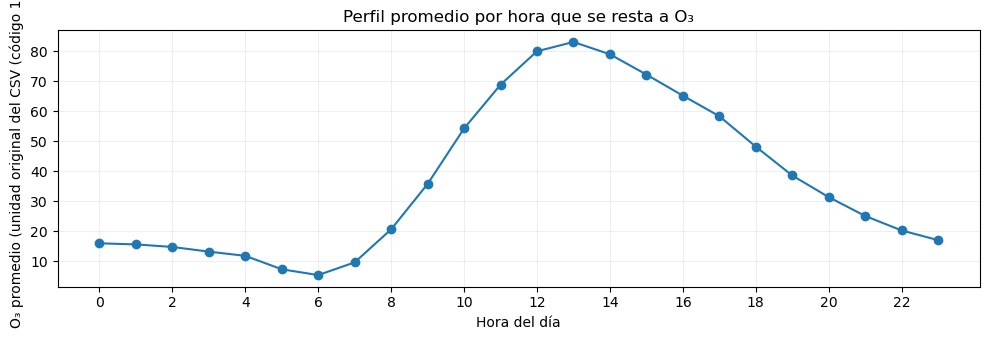

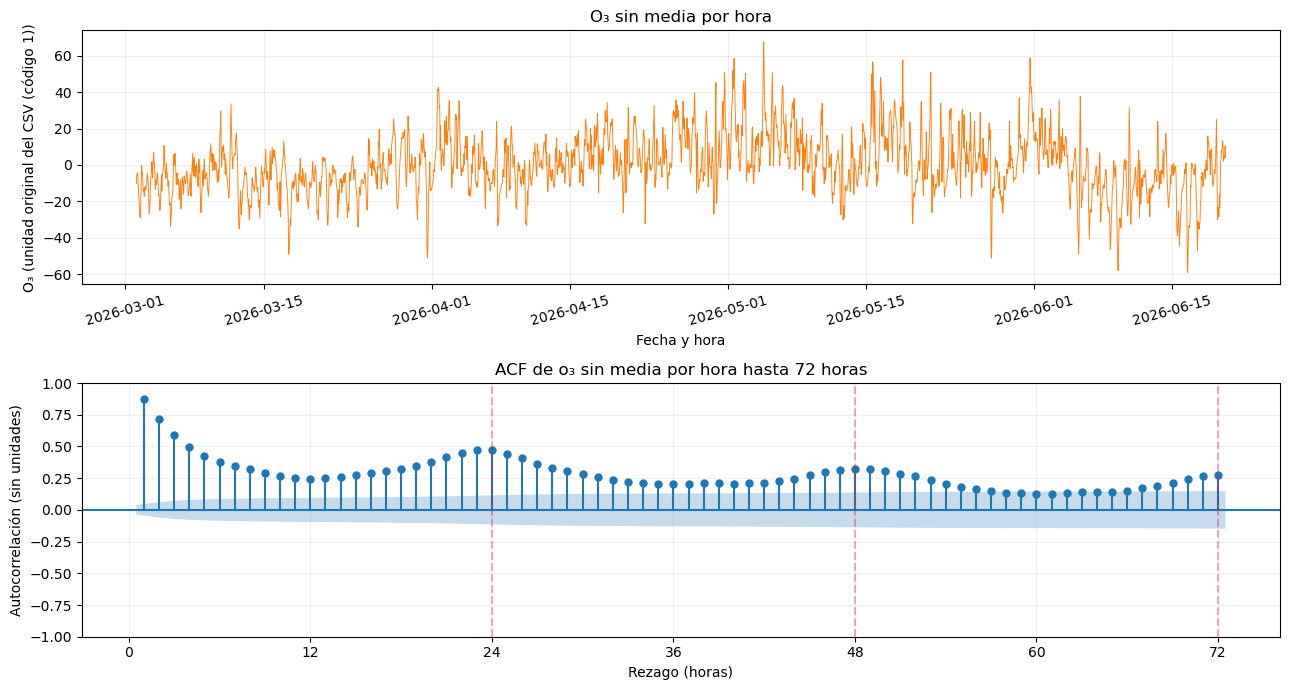

,0
serie,Sin media por hora
n_horas,2647
ADF_estadistico,-4.226648
ADF_p,0.000594
ADF_rezagos,22
ADF_n_efectivo,2624
ADF_critico_5pct,-2.862642
ADF_rechaza_raiz,True
KPSS_estadistico,1.21187
KPSS_p_reportado,≤0.01


**Interpretación:** Ambas rechazan: diagnóstico de nivel no concluyente. Restar una media diaria fija no garantiza eliminar cambios de nivel entre meses.

In [6]:
perfil_horario = y.groupby(y.index.hour).agg(["mean", "count", "std"])
perfil_horario.index.name = "hora_del_dia"
display(perfil_horario.round(3))
assert np.allclose(variantes_completas["Sin media por hora"].groupby(horas).mean(), 0, atol=1e-10)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(perfil_horario.index, perfil_horario["mean"], marker="o")
ax.set(title="Perfil promedio por hora que se resta a O₃", xlabel="Hora del día",
       ylabel=f"O₃ promedio ({UNIDAD})", xticks=range(0, 24, 2))
fig.tight_layout();plt.show()
graficar_serie_acf(comparables["Sin media por hora"], "O₃ sin media por hora", "#ff7f0e")
resultados_pruebas["Sin media por hora"] = diagnosticar(comparables["Sin media por hora"], "Sin media por hora")
display(pd.DataFrame([resultados_pruebas["Sin media por hora"]]).T)
display(Markdown("**Interpretación:** " + resultados_pruebas["Sin media por hora"]["lectura_conjunta"] + ". Restar una media diaria fija no garantiza eliminar cambios de nivel entre meses."))

## E. Restar la media de cada mes × hora

$$w_t = y_t - \bar y_{m(t),h(t)}.$$

Ahora las 14:00 de marzo tienen una media diferente de las 14:00 de abril. La interacción **mes × hora** permite que tanto el nivel como la forma del ciclo diario cambien por mes. No se resta una media mensual más una media horaria: se calcula una media para **cada combinación**.

Agrupamos por año–mes para evitar mezclar años si cambia la fuente. Algunas combinaciones incluyen un mes parcial: mostramos cuántas observaciones sostienen cada media. Al estimar estos promedios con el mismo tramo estudiado, la reducción de variación es descriptiva; no equivale a una validación predictiva y puede influir en las pruebas.

hora,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
mes,,,,,,,,,,,,,,,,,,,,,,,,
2026-03,15.37,14.43,12.83,10.23,10.13,7.26,4.94,6.42,13.75,25.44,40.32,51.34,59.43,62.64,62.69,59.65,57.48,51.94,40.61,31.84,26.97,21.13,15.97,15.48
2026-04,15.09,15.32,16.27,15.40,13.80,7.83,5.20,10.23,22.63,40.60,61.80,77.90,88.99,91.18,86.61,79.28,73.03,65.60,56.30,49.30,37.60,30.03,23.60,18.07
2026-05,19.37,18.35,16.21,14.53,11.87,6.90,5.48,11.87,26.55,44.97,67.40,85.53,101.91,104.77,96.49,84.16,71.65,65.52,57.52,44.84,37.55,29.90,25.15,21.00
2026-06,13.08,13.72,13.26,12.60,11.40,7.40,6.35,10.35,19.30,30.40,43.93,56.24,63.91,68.63,65.32,62.53,55.18,45.95,32.89,22.68,18.89,16.11,14.21,11.67


hora,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
mes,,,,,,,,,,,,,,,,,,,,,,,,
2026-03,30,30,30,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31
2026-04,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30
2026-05,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31
2026-06,20,20,20,20,20,20,20,20,20,20,19,19,19,19,19,19,19,19,19,19,19,19,19,19


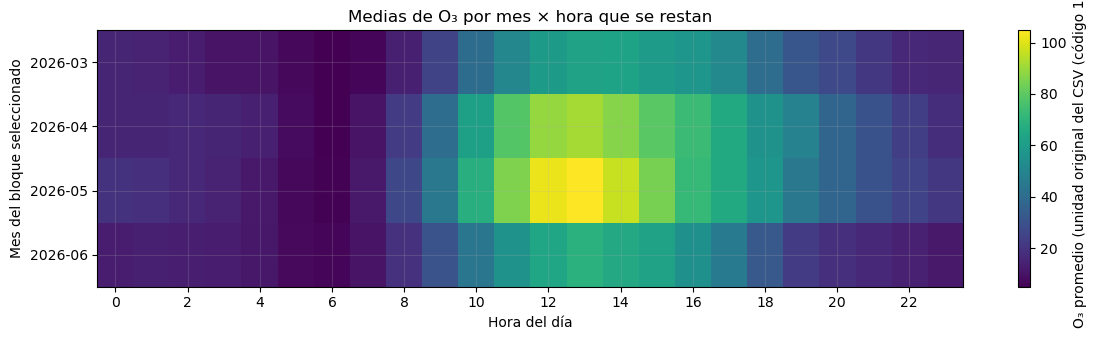

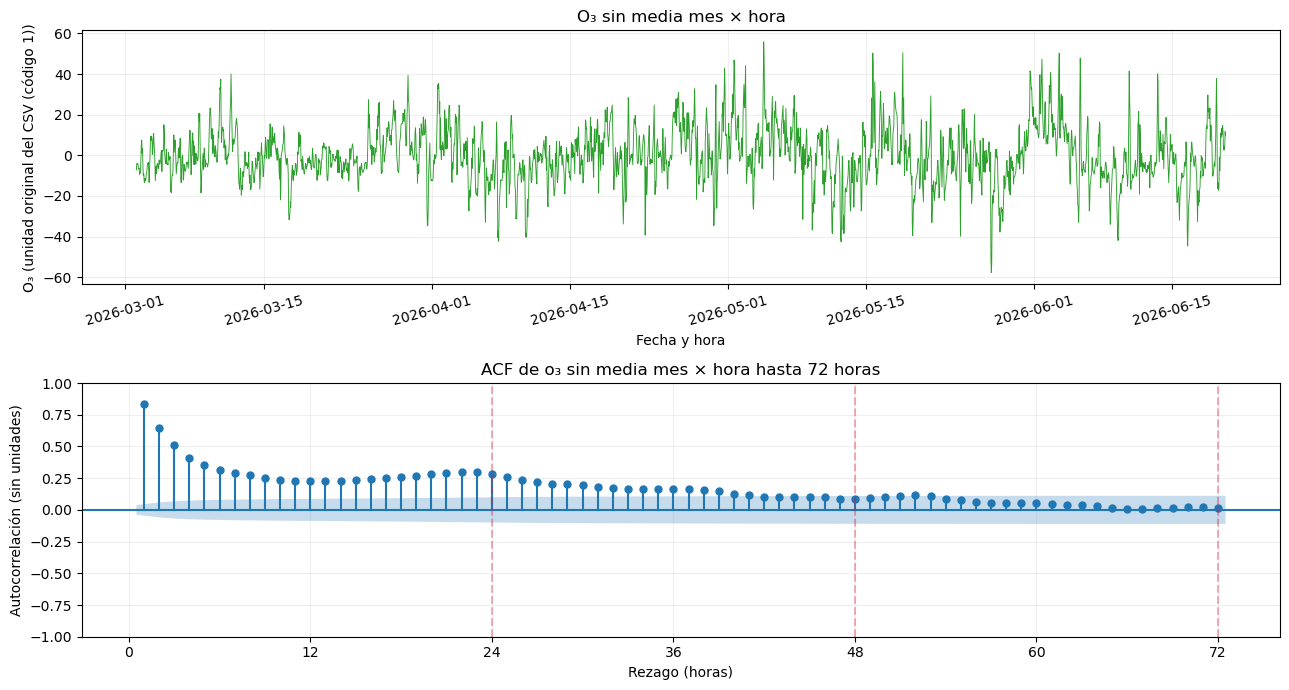

,0
serie,Sin media mes × hora
n_horas,2647
ADF_estadistico,-5.669605
ADF_p,0.000001
ADF_rezagos,21
ADF_n_efectivo,2625
ADF_critico_5pct,-2.862642
ADF_rechaza_raiz,True
KPSS_estadistico,0.120353
KPSS_p_reportado,≥0.10


**Interpretación:** Compatible con estacionariedad de nivel (en este tramo). Que las pruebas sean compatibles no asegura varianza constante, ausencia de autocorrelación o generalización a otros meses.

In [7]:
perfil_mensual = y.groupby([meses, horas]).agg(["mean", "count"]).unstack("hora")
medias_mes_hora = perfil_mensual["mean"]
conteos_mes_hora = perfil_mensual["count"]
display(medias_mes_hora.round(2))
display(conteos_mes_hora)
assert np.allclose(variantes_completas["Sin media mes × hora"].groupby([meses, horas]).mean(), 0, atol=1e-10)
fig, ax = plt.subplots(figsize=(12, 3.5))
im = ax.imshow(medias_mes_hora.to_numpy(), aspect="auto", cmap="viridis")
ax.set(title="Medias de O₃ por mes × hora que se restan", xlabel="Hora del día", ylabel="Mes del bloque seleccionado")
ax.set_xticks(range(0, 24, 2), labels=range(0, 24, 2))
ax.set_yticks(range(len(medias_mes_hora)), labels=medias_mes_hora.index.astype(str))
fig.colorbar(im, ax=ax, label=f"O₃ promedio ({UNIDAD})")
fig.tight_layout();plt.show()
graficar_serie_acf(comparables["Sin media mes × hora"], "O₃ sin media mes × hora", "#2ca02c")
resultados_pruebas["Sin media mes × hora"] = diagnosticar(comparables["Sin media mes × hora"], "Sin media mes × hora")
display(pd.DataFrame([resultados_pruebas["Sin media mes × hora"]]).T)
display(Markdown("**Interpretación:** " + resultados_pruebas["Sin media mes × hora"]["lectura_conjunta"] + ". Que las pruebas sean compatibles no asegura varianza constante, ausencia de autocorrelación o generalización a otros meses."))

## F. Diferencia de 24 horas y comparación con E

$$\Delta_{24}y_t = y_t-y_{t-24}.$$

Se diferencia la **serie original tratada**, no el residuo del inciso E. En una rejilla horaria regular, `diff(24)` compara una hora con la misma hora del día anterior. Las primeras 24 observaciones no tienen antecedente y por eso se excluyeron de la muestra común de todos los incisos.

La diferencia puede eliminar un componente diario estable sin estimar medias mensuales. También puede aumentar ruido e introducir autocorrelación negativa en el rezago 24: **una menor varianza o menor ACF no está garantizada**. Comparamos E y F en las mismas fechas, usando varianza muestral (`ddof=1`) y ACF hasta 72 h.

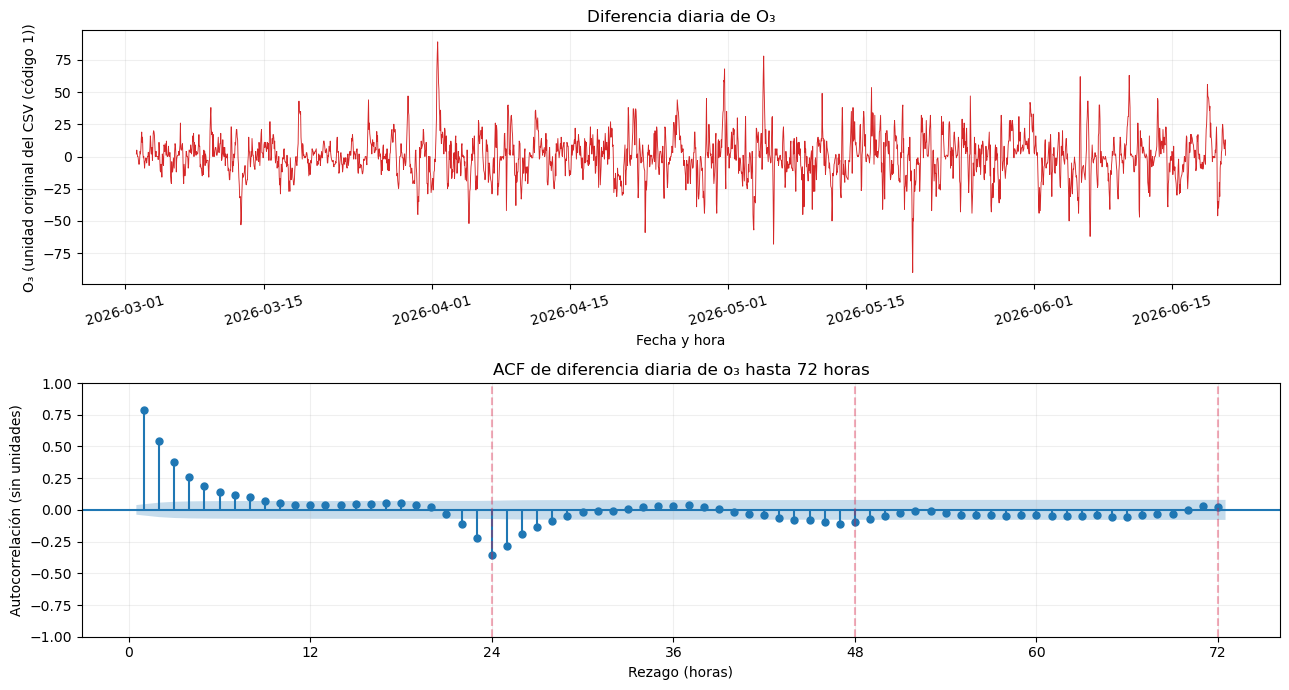

,0
serie,Diferencia 24 h
n_horas,2647
ADF_estadistico,-7.223591
ADF_p,0.0
ADF_rezagos,72
ADF_n_efectivo,2574
ADF_critico_5pct,-2.862664
ADF_rechaza_raiz,True
KPSS_estadistico,0.027322
KPSS_p_reportado,≥0.10


,n_horas,varianza_muestral,reduccion_varianza_vs_original_pct,ACF_1h,ACF_24h,ACF_48h,ACF_72h
serie,,,,,,,
Original,2647,929.6114,0.0000,0.9293,0.8488,0.8017,0.7849
Sin media por hora,2647,258.4462,72.1985,0.8737,0.4686,0.3247,0.2717
Sin media mes × hora,2647,183.1076,80.3028,0.8369,0.2824,0.0887,0.0122
Diferencia 24 h,2647,270.6201,70.8889,0.7840,-0.3558,-0.0970,0.0211


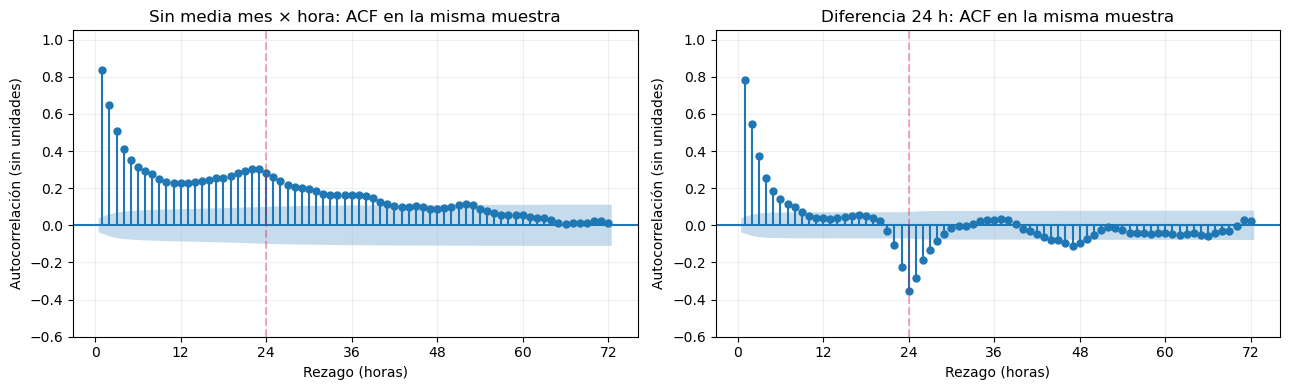

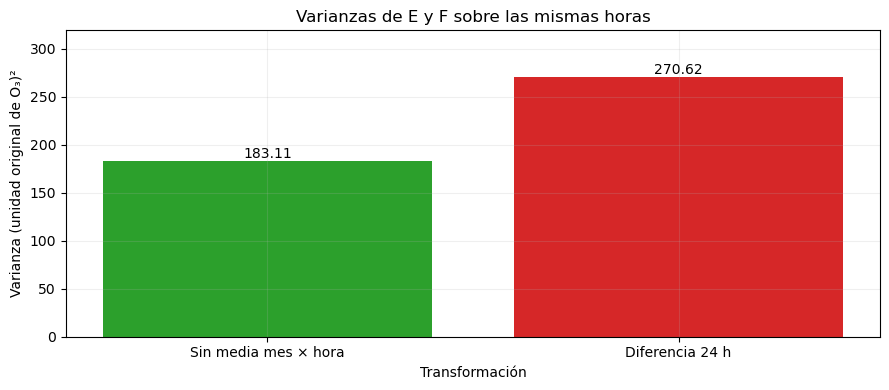

**Comparación:** la varianza de E es 183.11 y la de F 270.62: F/E = 1.478. ACF(24) cambia de 0.282 en E a -0.356 en F. La diferencia elimina parte del ciclo diario, pero su autocorrelación negativa de 24 h no representa independencia.

In [8]:
assert np.allclose(comparables["Diferencia 24 h"].to_numpy(),
                   y.iloc[24:].to_numpy() - y.iloc[:-24].to_numpy())
graficar_serie_acf(comparables["Diferencia 24 h"], "Diferencia diaria de O₃", "#d62728")
resultados_pruebas["Diferencia 24 h"] = diagnosticar(comparables["Diferencia 24 h"], "Diferencia 24 h")
display(pd.DataFrame([resultados_pruebas["Diferencia 24 h"]]).T)

comparacion = pd.DataFrame(index=comparables.columns)
comparacion.index.name = "serie"
comparacion["n_horas"] = len(comparables)
comparacion["varianza_muestral"] = comparables.var(ddof=1)
comparacion["reduccion_varianza_vs_original_pct"] = 100 * (1 - comparacion["varianza_muestral"] / comparables["Original"].var(ddof=1))
for nombre in comparables:
    rho = acf(comparables[nombre], nlags=MAX_LAG, fft=True)
    for lag in [1, 24, 48, 72]:
        comparacion.loc[nombre, f"ACF_{lag}h"] = rho[lag]
display(comparacion.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, nombre in zip(axes, ["Sin media mes × hora", "Diferencia 24 h"]):
    plot_acf(comparables[nombre].to_numpy(), lags=MAX_LAG, zero=False, fft=True, alpha=0.05, ax=ax)
    ax.set(title=nombre + ": ACF en la misma muestra", xlabel="Rezago (horas)",
           ylabel="Autocorrelación (sin unidades)", ylim=(-0.6, 1.05), xticks=np.arange(0, 73, 12))
    ax.axvline(24, color="crimson", linestyle="--", alpha=0.35)
fig.tight_layout();plt.show()
fig, ax = plt.subplots(figsize=(9, 4))
seleccion = comparacion.loc[["Sin media mes × hora", "Diferencia 24 h"], "varianza_muestral"]
ax.bar(seleccion.index, seleccion.to_numpy(), color=["#2ca02c", "#d62728"])
ax.set(title="Varianzas de E y F sobre las mismas horas", xlabel="Transformación",
       ylabel="Varianza (unidad original de O₃)²")
for i, valor in enumerate(seleccion):
    ax.text(i, valor, f"{valor:.2f}", ha="center", va="bottom")
ax.set_ylim(0, seleccion.max() * 1.18)
fig.tight_layout();plt.show()
var_e, var_f = seleccion.iloc[0], seleccion.iloc[1]
display(Markdown(f"**Comparación:** la varianza de E es {var_e:.2f} y la de F {var_f:.2f}: F/E = {var_f/var_e:.3f}. ACF(24) cambia de {comparacion.loc['Sin media mes × hora', 'ACF_24h']:.3f} en E a {comparacion.loc['Diferencia 24 h', 'ACF_24h']:.3f} en F. La diferencia elimina parte del ciclo diario, pero su autocorrelación negativa de 24 h no representa independencia."))

## Sensibilidad a la decisión sobre los huecos

Repetimos los diagnósticos con interpolación limitada a 3 horas. También se elige su mayor bloque continuo y se recortan las primeras 24 horas. Esta comprobación permite ver si las conclusiones cambian con el tratamiento; **el tramo y el tamaño de muestra también cambian**, por lo que no es una comparación causal del efecto de interpolar. No rellenamos las interrupciones largas ni comprimimos el eje del tiempo.

In [9]:
serie_3h, fill_3h = tratar_huecos(serie_original, 3)
y_3h = mayor_bloque(serie_3h)
h3 = pd.Series(y_3h.index.hour, index=y_3h.index)
m3 = pd.Series(y_3h.index.to_period("M"), index=y_3h.index)
variantes_3h = pd.DataFrame({
    "Original": y_3h,
    "Sin media por hora": y_3h - y_3h.groupby(h3).transform("mean"),
    "Sin media mes × hora": y_3h - y_3h.groupby([m3, h3]).transform("mean"),
    "Diferencia 24 h": y_3h.diff(24),
}).iloc[24:]
sensibilidad = []
if len(variantes_3h) > 2 * MAX_LAG + 5:
    for nombre in variantes_3h:
        res = diagnosticar(variantes_3h[nombre], nombre)
        sensibilidad.append({"max_hueco_interpolado_h": 3, "inicio": variantes_3h.index[0],
                             "fin": variantes_3h.index[-1], **res})
for nombre, res in resultados_pruebas.items():
    sensibilidad.append({"max_hueco_interpolado_h": MAX_GAP, "inicio": comparables.index[0],
                         "fin": comparables.index[-1], **res})
sensibilidad = pd.DataFrame(sensibilidad)
display(sensibilidad[["max_hueco_interpolado_h", "serie", "n_horas", "inicio", "fin",
                     "ADF_p", "KPSS_p_reportado", "lectura_conjunta"]])

,max_hueco_interpolado_h,serie,n_horas,inicio,fin,ADF_p,KPSS_p_reportado,lectura_conjunta
0,3,Original,1111,2026-03-26 15:00:00,2026-05-11 21:00:00,2.499508e-01,≤0.01,Evidencia de no estacionariedad
1,3,Sin media por hora,1111,2026-03-26 15:00:00,2026-05-11 21:00:00,8.648340e-18,≤0.01,Ambas rechazan: diagnóstico de nivel no conclu...
2,3,Sin media mes × hora,1111,2026-03-26 15:00:00,2026-05-11 21:00:00,7.483329e-19,≥0.10,Compatible con estacionariedad de nivel (en es...
3,3,Diferencia 24 h,1111,2026-03-26 15:00:00,2026-05-11 21:00:00,1.481223e-05,≥0.10,Compatible con estacionariedad de nivel (en es...
4,6,Original,2647,2026-03-02 03:00:00,2026-06-20 09:00:00,2.981637e-02,≤0.01,Ambas rechazan: diagnóstico de nivel no conclu...
5,6,Sin media por hora,2647,2026-03-02 03:00:00,2026-06-20 09:00:00,5.937071e-04,≤0.01,Ambas rechazan: diagnóstico de nivel no conclu...
6,6,Sin media mes × hora,2647,2026-03-02 03:00:00,2026-06-20 09:00:00,8.985375e-07,≥0.10,Compatible con estacionariedad de nivel (en es...
7,6,Diferencia 24 h,2647,2026-03-02 03:00:00,2026-06-20 09:00:00,2.080664e-10,≥0.10,Compatible con estacionariedad de nivel (en es...


## Resultados integrados y conclusiones

Leemos ADF y KPSS junto con ACF, cobertura y varianza. Una transformación que parece estacionaria aún puede conservar dependencia temporal. Además, una media mes × hora estimada con todo el tramo puede funcionar como descripción, pero para predecir habría que estimarla sólo con datos de entrenamiento y validar en fechas posteriores.

In [10]:
tabla_pruebas = pd.DataFrame(resultados_pruebas.values()).set_index("serie")
display(tabla_pruebas[["n_horas", "ADF_estadistico", "ADF_p", "ADF_rezagos",
                      "KPSS_estadistico", "KPSS_p_reportado", "KPSS_rezagos", "lectura_conjunta"]])
lineas = [
    f"**A — Huecos:** {int(faltante.sum())} horas faltantes de {len(serie_original)} ({100*faltante.mean():.2f}%), en {len(tabla_huecos)} huecos; el más largo dura {resumen_huecos.iloc[0]['mayor_hueco_h']:.0f} h. Se interpolaron {int(interpoladas.sum())} horas cortas y se conservaron vacíos los huecos largos.",
    f"**B — ACF:** la original tiene ACF(24)={acf_original[24]:.3f}, compatible con un componente diario persistente. El diagnóstico principal cubre {comparables.index[0]} a {comparables.index[-1]}, con {len(comparables)} horas; no todo 2026.",
]
for letra, nombre in [('C','Original'), ('D','Sin media por hora'), ('E','Sin media mes × hora'), ('F','Diferencia 24 h')]:
    res = resultados_pruebas[nombre]
    lineas.append(f"**{letra} — {nombre}:** ADF p={res['ADF_p']:.4g}; KPSS p {res['KPSS_p_reportado']}. {res['lectura_conjunta']}.")
lineas.append(f"**E frente a F:** varianzas {var_e:.2f} frente a {var_f:.2f}; la menor en esta muestra corresponde a {'E' if var_e < var_f else 'F'}. ACF(24): {comparacion.loc['Sin media mes × hora','ACF_24h']:.3f} frente a {comparacion.loc['Diferencia 24 h','ACF_24h']:.3f}. Comparar el valor absoluto importa: un coeficiente negativo tampoco significa ausencia de dependencia.")
lineas.append("**Límites:** el umbral de interpolación y la selección del bloque influyen; sólo hay parte del año; las medias se estiman en la misma muestra y KPSS tiene p-values tabulados limitados. No se concluye estacionariedad para otros meses ni ausencia de dependencia sólo por pasar ADF/KPSS.")
display(Markdown("\n\n".join(lineas)))

,n_horas,ADF_estadistico,ADF_p,ADF_rezagos,KPSS_estadistico,KPSS_p_reportado,KPSS_rezagos,lectura_conjunta
serie,,,,,,,,
Original,2647,-3.058064,2.981637e-02,69,1.251012,≤0.01,25,Ambas rechazan: diagnóstico de nivel no conclu...
Sin media por hora,2647,-4.226648,5.937071e-04,22,1.211870,≤0.01,27,Ambas rechazan: diagnóstico de nivel no conclu...
Sin media mes × hora,2647,-5.669605,8.985375e-07,21,0.120353,≥0.10,26,Compatible con estacionariedad de nivel (en es...
Diferencia 24 h,2647,-7.223591,2.080664e-10,72,0.027322,≥0.10,24,Compatible con estacionariedad de nivel (en es...


**A — Huecos:** 228 horas faltantes de 5088 (4.48%), en 68 huecos; el más largo dura 49 h. Se interpolaron 171 horas cortas y se conservaron vacíos los huecos largos.

**B — ACF:** la original tiene ACF(24)=0.849, compatible con un componente diario persistente. El diagnóstico principal cubre 2026-03-02 03:00:00 a 2026-06-20 09:00:00, con 2647 horas; no todo 2026.

**C — Original:** ADF p=0.02982; KPSS p ≤0.01. Ambas rechazan: diagnóstico de nivel no concluyente.

**D — Sin media por hora:** ADF p=0.0005937; KPSS p ≤0.01. Ambas rechazan: diagnóstico de nivel no concluyente.

**E — Sin media mes × hora:** ADF p=8.985e-07; KPSS p ≥0.10. Compatible con estacionariedad de nivel (en este tramo).

**F — Diferencia 24 h:** ADF p=2.081e-10; KPSS p ≥0.10. Compatible con estacionariedad de nivel (en este tramo).

**E frente a F:** varianzas 183.11 frente a 270.62; la menor en esta muestra corresponde a E. ACF(24): 0.282 frente a -0.356. Comparar el valor absoluto importa: un coeficiente negativo tampoco significa ausencia de dependencia.

**Límites:** el umbral de interpolación y la selección del bloque influyen; sólo hay parte del año; las medias se estiman en la misma muestra y KPSS tiene p-values tabulados limitados. No se concluye estacionariedad para otros meses ni ausencia de dependencia sólo por pasar ADF/KPSS.

## Referencias y archivos

- [Fuente de datos solicitada: SIMAT, CSV horario 2026](https://aire.cdmx.gob.mx/descargas/Opendata/anuales_horarios_gz/contaminantes_2026.csv.gz).
- [UIZ corresponde a UAM Iztapalapa: informe oficial SIMAT](https://www.aire.cdmx.gob.mx/descargas/monitoreo/2017_audit_report_Final.pdf).
- [ADF: documentación oficial de statsmodels](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html).
- [KPSS: documentación oficial de statsmodels](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.kpss.html).
- [ACF: documentación oficial de statsmodels](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.acf.html).

**Único archivo de trabajo y entrega:** `Notebook3.ipynb`. Los datos de UIZ, las funciones, tablas, figuras y conclusiones están incorporados en él. Ninguna celda crea carpetas o exporta archivos externos.